# 🎬 Chương 3 — Dataset 3: IMDB Reviews — Stacked RNN
## Kỹ thuật: Stacked RNN + Binary Sentiment Classification

**Pipeline:** EDA → Preprocessing → Stacked RNN → Train → Evaluate

---

In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress TF log messages (INFO & WARNING)
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # Suppress oneDNN custom operations warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import re, glob, warnings
import nltk
from nltk.corpus import stopwords

import random

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')  # Suppress TF logging warnings
tf.autograph.set_verbosity(0)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})

DATA_DIR = '../data/imdb_reviews'
SAVE_DIR = '../results/imdb_stacked_rnn'
os.makedirs(SAVE_DIR, exist_ok=True)

VOCAB_SIZE  = 20000
MAX_LEN     = 500
EMBED_DIM   = 128
EPOCHS      = 10
BATCH_SIZE  = 128
MAX_SAMPLES = 50000

print(f'TF: {tf.__version__}')

TF: 2.21.0


## 📂 1. Load IMDB Dataset

In [2]:
csv_files = glob.glob(f'{DATA_DIR}/**/*.csv', recursive=True) + glob.glob(f'{DATA_DIR}/*.csv')
print('Found:', csv_files)
df = pd.read_csv(csv_files[0])
print(f'Shape: {df.shape}')
df.head(10)

Found: ['../data/imdb_reviews/IMDB Dataset.csv', '../data/imdb_reviews/IMDB Dataset.csv']
Shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive
6,I sure would like to see a resurrection of a u...,positive
7,"This show was an amazing, fresh & innovative i...",negative
8,Encouraged by the positive comments about this...,negative
9,If you like original gut wrenching laughter yo...,positive


In [3]:
# Identify columns
text_col  = [c for c in df.columns if any(k in c.lower() for k in ['review','text','comment'])][0]
label_col = [c for c in df.columns if any(k in c.lower() for k in ['sentiment','label','rating'])][0]
print(f'Text: {text_col}, Label: {label_col}')

df = df[[text_col, label_col]].dropna()
df.columns = ['text', 'label']

# Binary encode
if df['label'].dtype == object:
    positive_keys = ['positive', 'pos', '1', 'good']
    df['label'] = df['label'].str.lower().apply(
        lambda x: 1 if any(k in x for k in positive_keys) else 0)

NUM_CLASSES = df['label'].nunique()
print(f'Label distribution:\n{df["label"].value_counts()}')

Text: review, Label: sentiment
Label distribution:
label
1    25000
0    25000
Name: count, dtype: int64


## 📊 2. EDA

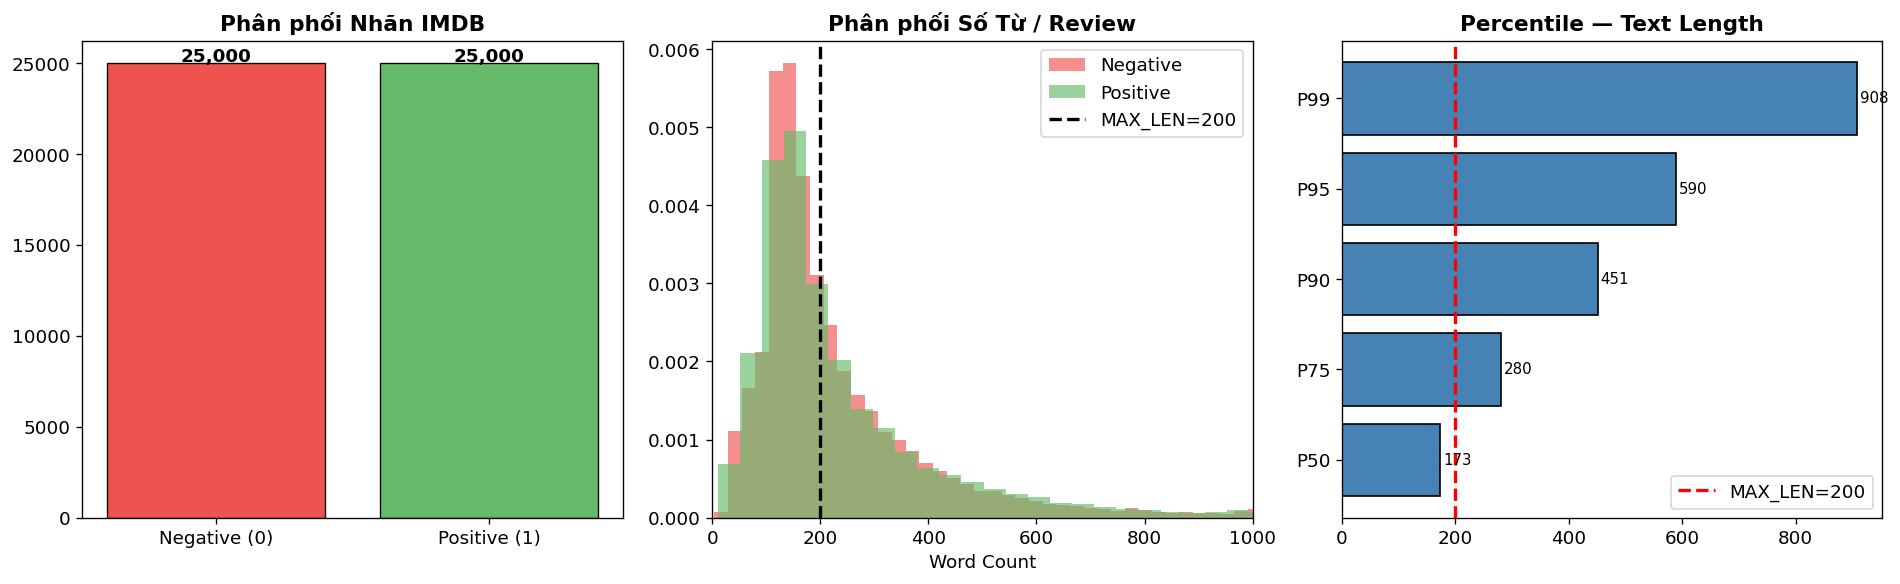

In [4]:
df['text_len'] = df['text'].apply(lambda x: len(str(x).split()))
label_names = {0: 'Negative', 1: 'Positive'}
colors = ['#EF5350', '#66BB6A']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar chart of label distribution
counts = df['label'].value_counts().sort_index()
axes[0].bar(['Negative (0)', 'Positive (1)'], counts.values,
            color=colors, edgecolor='black', linewidth=0.8)
for i, val in enumerate(counts.values):
    axes[0].text(i, val+100, f'{val:,}', ha='center', fontweight='bold')
axes[0].set_title('Phân phối Nhãn IMDB')

# Word count distribution per sentiment
for lbl, color, name in [(0,'#EF5350','Negative'), (1,'#66BB6A','Positive')]:
    axes[1].hist(df[df['label']==lbl]['text_len'],
                 bins=60, alpha=0.65, color=color, label=name, density=True)
axes[1].axvline(MAX_LEN, color='black', linestyle='--', lw=2, label=f'MAX_LEN={MAX_LEN}')
axes[1].set_title('Phân phối Số Từ / Review')
axes[1].set_xlabel('Word Count')
axes[1].legend()
axes[1].set_xlim(0, 1000)

# Percentile coverage
percentiles = [50, 75, 90, 95, 99]
pct_values  = np.percentile(df['text_len'], percentiles)
axes[2].barh([f'P{p}' for p in percentiles], pct_values,
              color='steelblue', edgecolor='black')
axes[2].axvline(MAX_LEN, color='red', linestyle='--', lw=2, label=f'MAX_LEN={MAX_LEN}')
axes[2].set_title('Percentile — Text Length')
axes[2].legend()
for i, v in enumerate(pct_values):
    axes[2].text(v+5, i, f'{v:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_eda_overview.png', bbox_inches='tight')
plt.show()

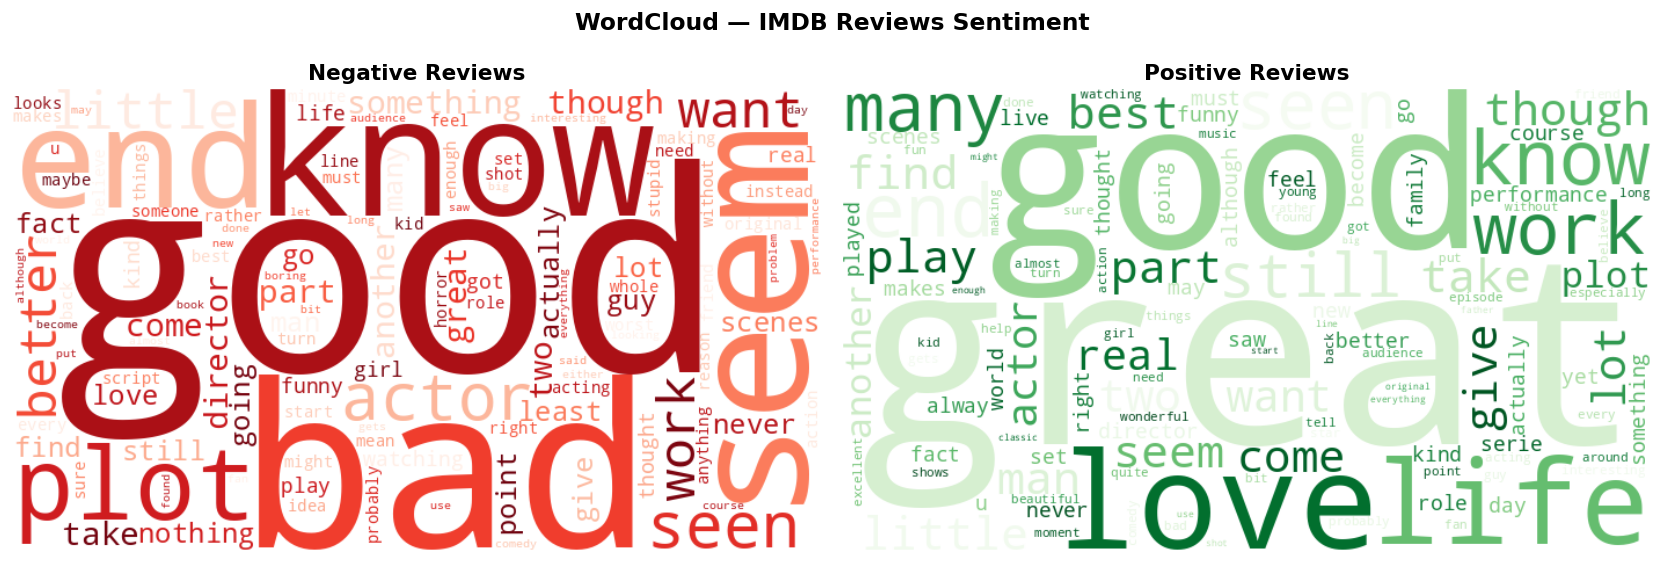

In [5]:
stop_words = set(stopwords.words('english'))

# domain_stops = {'movie', 'film', 'one', 'character', 'make', 'even', 'time', 'watch', 'see', 'story', 'br', 'really', 'much', 'well'}
domain_stops = {
    'movie', 'film', 'one', 'character', 'make', 'even', 'time', 'watch', 
    'see', 'story', 'br', 'really', 'much', 'well', 
    'movies', 'films', 'characters', 'show', 'scene', 'people', 'think', 
    'way', 'made', 'look', 'say', 'first', 'thing'
}
stop_words = stop_words.union(domain_stops)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (lbl, title, cmap) in zip(axes, [
    (0, 'Negative Reviews', 'Reds'),
    (1, 'Positive Reviews', 'Greens')
]):
    corpus = ' '.join(df[df['label']==lbl]['text'].apply(clean_text).tolist())
    wc = WordCloud(width=700, height=400, max_words=120,
                   colormap=cmap, background_color='white').generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13)

plt.suptitle('WordCloud — IMDB Reviews Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_wordclouds.png', bbox_inches='tight')
plt.show()

## 📂 3. Preprocessing

In [6]:
df['clean'] = df['text'].apply(clean_text)
X = df['clean'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train),
                             maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(tokenizer.texts_to_sequences(X_test),
                             maxlen=MAX_LEN, padding='post', truncating='post')

print(f'Train: {X_train_pad.shape}, Test: {X_test_pad.shape}')

Train: (40000, 200), Test: (10000, 200)


## 🤖 4. Model Architecture

In [7]:
loss_fn    = 'binary_crossentropy'
out_units  = 1
activation = 'sigmoid'

model = models.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN, name='embedding'),
    layers.SpatialDropout1D(0.2),
    
    layers.Bidirectional(layers.SimpleRNN(128, return_sequences=True), name='bi_rnn_1'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Bidirectional(layers.SimpleRNN(64), name='bi_rnn_2'),
    layers.Dropout(0.3),
    
    layers.Dense(64, activation='relu'),
    layers.Dense(out_units, activation=activation, name='output')
], name='BiRNN_IMDB')

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss=loss_fn,
              metrics=['accuracy'])
model.summary()

Model: "BiRNN_IMDB"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 200, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_rnn_1 (Bidirectional)        │ (None, 200, 256)       │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_rnn_2 (Bidirectional)        │ (None, 128)            │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,676,225 (10.21 MB)

 Trainable params: 2,675,713 (10.21 MB)

 Non-trainable params: 512 (2.00 KB)

## 🚀 5. Training

In [8]:
history = model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)
    ],
    verbose=1
)

Epoch 1/10


266/266 ━━━━━━━━━━━━━━━━━━━━ 30s 79ms/step - accuracy: 0.5008 - loss: 0.7010 - val_accuracy: 0.5135 - val_loss: 0.6923 - learning_rate: 0.0010
Epoch 2/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.5020 - loss: 0.6944 - val_accuracy: 0.5607 - val_loss: 0.6928 - learning_rate: 0.0010
Epoch 3/10
265/266 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5032 - loss: 0.6933
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
266/266 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.5072 - loss: 0.6930 - val_accuracy: 0.4997 - val_loss: 0.6923 - learning_rate: 0.0010
Epoch 4/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.5822 - loss: 0.6703 - val_accuracy: 0.5128 - val_loss: 0.6890 - learning_rate: 5.0000e-04
Epoch 5/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 13s 45ms/step - accuracy: 0.6668 - loss: 0.6196 - val_accuracy: 0.6815 - val_loss: 0.5990 - learning_rate: 5.0000e-04
Epoch 6/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step - accuracy: 0.7473 - loss: 

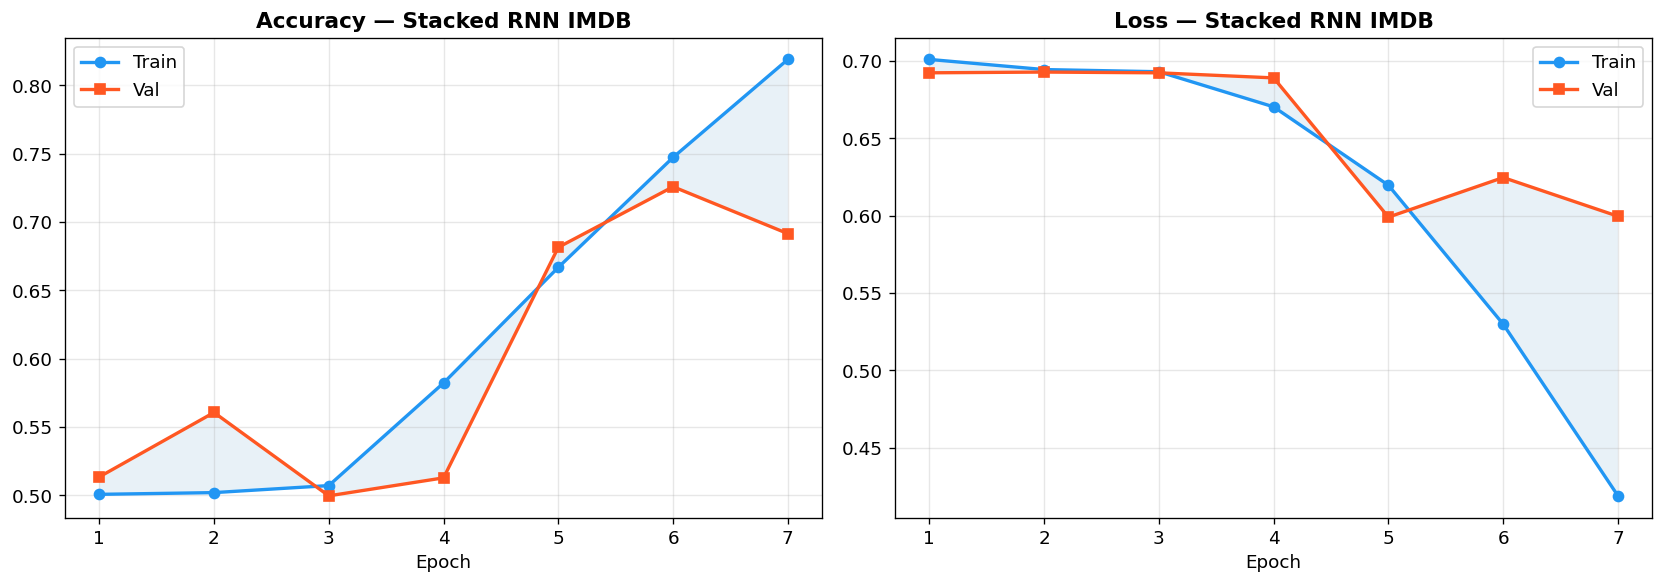

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
eps = range(1, len(history.history['accuracy'])+1)
for ax, (tr, vl, metric) in zip(axes, [ 
    ('accuracy','val_accuracy','Accuracy'),
    ('loss','val_loss','Loss')
]):
    ax.plot(eps, history.history[tr], 'o-', color='#2196F3', lw=2, label='Train')
    ax.plot(eps, history.history[vl], 's-', color='#FF5722', lw=2, label='Val')
    ax.fill_between(eps, history.history[tr], history.history[vl], alpha=0.1)
    ax.set_title(f'{metric} — Stacked RNN IMDB')
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/03_training_history.png', bbox_inches='tight')
plt.show()

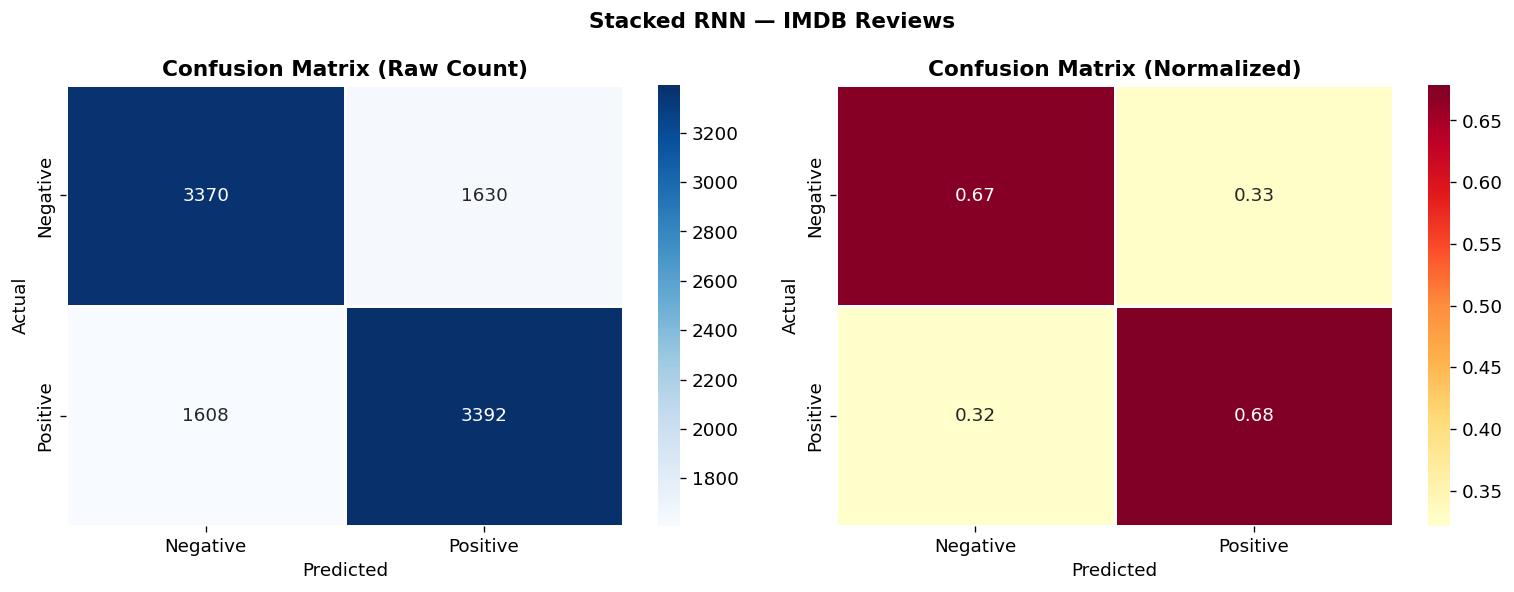

              precision    recall  f1-score   support

    Negative       0.68      0.67      0.68      5000
    Positive       0.68      0.68      0.68      5000

    accuracy                           0.68     10000
   macro avg       0.68      0.68      0.68     10000
weighted avg       0.68      0.68      0.68     10000



In [10]:
y_pred_prob = model.predict(X_test_pad, verbose=0).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            linewidths=0.8, ax=axes[0])
axes[0].set_title('Confusion Matrix (Raw Count)')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

# Normalized
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            linewidths=0.8, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')

plt.suptitle('Stacked RNN — IMDB Reviews', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/04_confusion_matrix.png', bbox_inches='tight')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

In [11]:
test_samples = [
    "This movie was absolutely fantastic! The acting was superb.",
    "Terrible film. Complete waste of time and money.",
    "It was okay, nothing special but not bad either."
]

cleaned  = [clean_text(s) for s in test_samples]
seqs     = pad_sequences(tokenizer.texts_to_sequences(cleaned),
                          maxlen=MAX_LEN, padding='post')
scores   = model.predict(seqs, verbose=0).flatten()

print('=== INFERENCE DEMO ===')
for s, score in zip(test_samples, scores):
    label = 'POSITIVE' if score >= 0.5 else 'NEGATIVE'
    print(f'Text  : {s}')
    print(f'Score : {score:.4f} → {label}\n')

=== INFERENCE DEMO ===
Text  : This movie was absolutely fantastic! The acting was superb.
Score : 0.8326 → POSITIVE

Text  : Terrible film. Complete waste of time and money.
Score : 0.2563 → NEGATIVE

Text  : It was okay, nothing special but not bad either.
Score : 0.2863 → NEGATIVE



In [12]:
best_acc = max(history.history['val_accuracy'])
with open(f'{SAVE_DIR}/report.txt', 'w') as f:
    f.write('IMDB Reviews — Stacked RNN\n' + '='*50 + '\n')
    f.write(f'Best Val Accuracy: {best_acc:.4f}\n')
    f.write(f'Total Params: {model.count_params():,}\n\n')
    f.write(classification_report(y_test, y_pred, target_names=['Negative','Positive']))

print('✅ IMDB Stacked RNN Done! Saved to', SAVE_DIR)

✅ IMDB Stacked RNN Done! Saved to ../results/imdb_stacked_rnn
